In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Exploration

In [2]:
births = Table.read_table('baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [3]:
births.select('Maternal Smoker', 'Birth Weight').show(5)

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136


In [4]:
means_table = (births.select('Maternal Smoker', 'Birth Weight')
               .group('Maternal Smoker', np.average)
              )
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


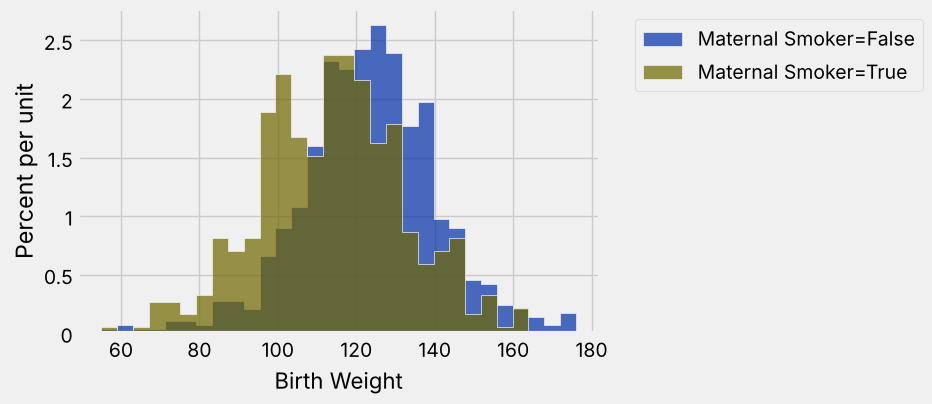

In [5]:
births.select('Maternal Smoker', 'Birth Weight').hist('Birth Weight', group='Maternal Smoker', bins = 30)

In [6]:
observed_difference = means_table.column(1).item(1) - means_table.column(1).item(0)
observed_difference

-9.266142572024918

## assume null hypothesis

In [7]:
births.select('Maternal Smoker').show(5)

Maternal Smoker
False
False
True
True
False


In [8]:
shuffled_grp=births.select('Maternal Smoker').sample(with_replacement=False)
shuffled_grp.show(5)

Maternal Smoker
True
False
False
True
True


In [9]:
simulated_births = Table().with_columns('Shuffled Maternal Smoker', shuffled_grp.column(0),
                                        'Birth Weight', births.column('Birth Weight'))
simulated_births.show(5)

Shuffled Maternal Smoker,Birth Weight
True,120
False,113
False,128
True,108
True,136


In [10]:
simulated_births.group('Shuffled Maternal Smoker', np.average)

Shuffled Maternal Smoker,Birth Weight average
False,119.466
True,119.458


In [11]:
means_array = simulated_births.group('Shuffled Maternal Smoker', np.average).column(1)
means_array

array([ 119.46573427,  119.45751634])

In [12]:
means_array.item(1) - means_array.item(0)

-0.008217925864983044

In [13]:
def simulated_difference(table, group_label, numeric_label, function):
    """
    Arguments
        -name of table
        -col label of categorical variable
        -col label of numerical variable
        -statistic to be calculated
    Returns: difference in statistics of the two groups
    """
    shuffled_grp = table.select(group_label).sample(with_replacement=False)
    simulated_table = Table().with_columns(group_label, shuffled_grp.column(0),
                                           numeric_label, table.column(numeric_label))
    stats_array = simulated_table.group(group_label, function).column(1)
    return stats_array.item(1) - stats_array.item(0)

In [14]:
simulated_difference(births, 'Maternal Smoker', 'Birth Weight', np.average)

0.6893459481694748